In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/AI/week1/diabetes.csv')

# 확인
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [2]:
df2=df.drop('Outcome',axis=1) # Outcome 열을 제거한 데이터를 df2에 저장
df.head()                     # df의 상위 5개 행을 출력


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
y=df2['BMI']       # BMI 열을 타깃값(y)으로 저장
y.value_counts()    # BMI 값들의 개수 확인
y


,BMI
0,33.6
1,26.6
2,23.3
3,28.1
4,43.1
...,...
763,32.9
764,36.8
765,26.2
766,30.1


In [4]:
X=df2.drop('BMI',axis=1)    # BMI 열을 제외한 나머지 열을 입력값(X)으로 저장
X.head()                    # X의 상위 5개 행을 출력

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,0.627,50
1,1,85,66,29,0,0.351,31
2,8,183,64,0,0,0.672,32
3,1,89,66,23,94,0.167,21
4,0,137,40,35,168,2.288,33


In [5]:
from sklearn.model_selection import train_test_split        # 데이터를 학습용/테스트용으로 나누는 함수 불러오기

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=0)    # 데이터를 75%를 학습용 25%를 테스트용으로 나눔 난수를 0으로하여 시드 고정


In [6]:
from sklearn.metrics import mean_squared_error      # 평균제곱오차(MSE)를 계산하는 함수 불러오기

In [7]:
from sklearn.linear_model import LinearRegression   # LinearRegression(회귀) 모델 불러오기

model = LinearRegression()      # LinearRegression 모델 생성
model.fit(X_train, y_train)      # 학습 데이터로 모델 학습
ly_preds = model.predict(X_test)    #결과 예측

print('평균제곱오차', mean_squared_error(ly_preds, y_test))   # sklearn 함수로 평균제곱오차(MSE) 출력

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)   # numpy로 평균제곱오차 계산

print('평균제곱오차', mse_np(ly_preds, y_test))                 # numpy로 계산한 평균제곱오차 출력

def mse(actual, predicted):                                       # 평균제곱오차를 구현해서 계산
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(ly_preds, y_test))                  # 직접 구현한 함수로 평균제곱오차 출력

평균제곱오차 52.23558099742443
평균제곱오차 52.23558099742443
평균제곱오차 52.23558099742445


In [8]:
from sklearn.tree import DecisionTreeRegressor             # DecisionTreeRegressor(회귀) 모델 불러오기

model = DecisionTreeRegressor(random_state=0)              # DecisionTreeRegressor(회귀) 모델 생성
model.fit(X_train, y_train)                               # 학습 데이터로 모델 학습
ly_preds = model.predict(X_test)                          #결과 예측

print('평균제곱오차', mean_squared_error(ly_preds, y_test))    # sklearn 함수로 평균제곱오차(MSE) 출력

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)   # numpy로 평균제곱오차 계산

print('평균제곱오차', mse_np(ly_preds, y_test))                 # numpy로 계산한 평균제곱오차 출력

def mse(actual, predicted):                                       # 평균제곱오차를 구현해서 계산
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(ly_preds, y_test))                  # 직접 구현한 함수로 평균제곱오차 출력

평균제곱오차 78.40718749999999
평균제곱오차 78.40718749999999
평균제곱오차 78.40718749999998


In [9]:
from sklearn.ensemble import RandomForestRegressor    # RandomForestRegressor(회귀) 모델 불러오기

model = RandomForestRegressor(random_state=0)     #RandomForestRegressor 모델 생성
model.fit(X_train, y_train)      # 학습 데이터로 모델 학습
ly_preds = model.predict(X_test)    #결과 예측

print('평균제곱오차', mean_squared_error(ly_preds, y_test))   # sklearn 함수로 평균제곱오차(MSE) 출력

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)   # numpy로 평균제곱오차 계산

print('평균제곱오차', mse_np(ly_preds, y_test))                 # numpy로 계산한 평균제곱오차 출력

def mse(actual, predicted):                                       # 평균제곱오차를 구현해서 계산
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(ly_preds, y_test))                  # 직접 구현한 함수로 평균제곱오차 출력

평균제곱오차 45.315124843750006
평균제곱오차 45.315124843750006
평균제곱오차 45.315124843750006


In [10]:
from sklearn.neighbors import KNeighborsRegressor

ly_knn = KNeighborsRegressor(n_neighbors=5)
ly_knn.fit(X_train, y_train)

pred_knn = ly_knn.predict(X_test)

print ("\n--- KNeighborsRegressor ---")

print('평균제곱오차', mean_squared_error(pred_knn, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(pred_knn, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(pred_knn, y_test))


--- KNeighborsRegressor ---
평균제곱오차 49.96783541666665
평균제곱오차 49.96783541666665
평균제곱오차 49.967835416666645


In [11]:
# K값의 최적값을 찾기 위해 for문을 30까지 돌리고 그래프로 표현 Regression 에서는 MSE 값이 가장 작은값이 최적값


--- KNeighborsRegressor ---
최적의 k: 11
최소 평균제곱오차: 44.92689221763086
평균제곱오차(sklearn) 44.92689221763086
평균제곱오차(numpy) 44.92689221763086
평균제곱오차(직접구현) 44.92689221763086


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

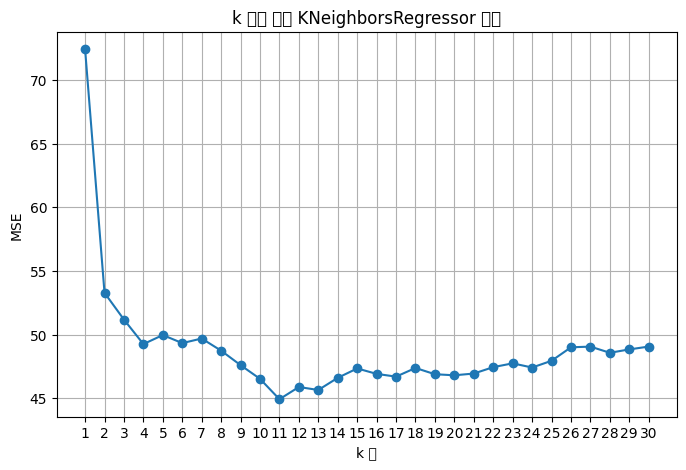

In [12]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

k_list = []
mse_list = []

#최적 k값 찾기
for k in range(1, 31):
    ly_knn = KNeighborsRegressor(n_neighbors=k)
    ly_knn.fit(X_train, y_train)

    pred_knn = ly_knn.predict(X_test)

    error = mean_squared_error(y_test, pred_knn)

    k_list.append(k)
    mse_list.append(error)

best_k = k_list[np.argmin(mse_list)]
best_mse = min(mse_list)

print("\n--- KNeighborsRegressor ---")
print("최적의 k:", best_k)
print("최소 평균제곱오차:", best_mse)

# 최적 k로 다시 예측
best_model = KNeighborsRegressor(n_neighbors=best_k)
best_model.fit(X_train, y_train)
pred_knn = best_model.predict(X_test)

print('평균제곱오차(sklearn)', mean_squared_error(y_test, pred_knn))
print('평균제곱오차(numpy)', mse_np(y_test, pred_knn))
print('평균제곱오차(직접구현)', mse(y_test, pred_knn))

plt.figure(figsize=(8, 5))
plt.plot(k_list, mse_list, marker='o')
plt.xlabel("k 값")
plt.ylabel("MSE")
plt.title("k 값에 따른 KNeighborsRegressor 성능")
plt.xticks(range(1, 31))
plt.grid(True)
plt.show()